In [361]:
import numpy as np
import pandas as pd

Data Loading and Cleaning

In [362]:
reddit_data = pd.read_csv('Reddit_data.csv', sep=',', on_bad_lines='skip', encoding='latin-1')
reddit_data.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [363]:
reddit_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  37149 non-null  object
 1   category       37249 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 582.1+ KB


In [364]:
reddit_data.describe()

,category
count,37249.000000
mean,0.202771
std,0.778515
min,-1.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [365]:
reddit_data.shape

(37249, 2)

In [366]:
reddit_data['category'].value_counts()

category
 1    15830
 0    13142
-1     8277
Name: count, dtype: int64

In [367]:
reddit_data['clean_comment'].values

array([' family mormon have never tried explain them they still stare puzzled from time time like some kind strange creature nonetheless they have come admire for the patience calmness equanimity acceptance and compassion have developed all the things buddhism teaches ',
       'buddhism has very much lot compatible with christianity especially considering that sin and suffering are almost the same thing suffering caused wanting things shouldn want going about getting things the wrong way christian this would mean wanting things that don coincide with god will and wanting things that coincide but without the aid jesus buddhism could also seen proof god all mighty will and omnipotence certainly christians are lucky have one such christ there side but what about everyone else well many christians believe god grace salvation and buddhism god way showing grace upon others would also help study the things jesus said and see how buddha has made similar claims such rich man getting into heave

In [368]:
reddit_data.sample(10)['clean_comment'].values

array(['good job aap',
       'ani ccs cabinet committee security meeting has now concluded ',
       'karma whore this reposted many effing times ',
       'but two years for displaying logo seriously ',
       'its their way life their ideologies and beliefs they are hate mongering people man they dont just dislike hindus they hate everyone else this comes from first hand experience cuz live city where muslim numbers are high and they are always creating some sort discomfort bad some places you are not muslim you wouldnt dare enter the area honestly dont feel safe when around them ',
       ' promoting himself when whole country want him see action against pakistan ',
       'feku let first talk about why the public spending health care only gdp ',
       'question for those around here who vehemently objected farmer loan waivers are these corporate handouts acceptable ',
       'well done ndtv cell ',
       'this what happens when you raise the expectations however atleast somethin

In [369]:
reddit_data.isnull().sum()

clean_comment    100
category           0
dtype: int64

In [370]:
reddit_data[reddit_data['clean_comment'].isnull()]

,clean_comment,category
413,NaN,0
605,NaN,0
2422,NaN,0
2877,NaN,0
3307,NaN,0
...,...,...
35975,NaN,0
36036,NaN,0
37043,NaN,0
37111,NaN,0


In [371]:
reddit_data.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [372]:
reddit_data.dropna(inplace=True)

In [373]:
reddit_data.isnull().sum()

clean_comment    0
category         0
dtype: int64

In [374]:
reddit_data.shape

(37149, 2)

In [375]:
reddit_data.duplicated().sum()

np.int64(350)

In [376]:
reddit_data[reddit_data.duplicated()]

,clean_comment,category
375,,0
392,,0
617,aurum mom,0
651,,0
1222,,0
...,...,...
36915,who won,0
37044,,0
37125,hari,0
37158,top kek,1


In [377]:
reddit_data.drop_duplicates(inplace=True)

In [378]:
reddit_data.shape

(36799, 2)

In [379]:
reddit_data.duplicated().sum()

np.int64(0)

In [380]:
## Check for empty comments after stripping whitespace
reddit_data[(reddit_data['clean_comment'].str.strip() == '')]

,clean_comment,category
181,,0
4432,\n,0
10592,,0
16173,,0
32149,\n,0
34959,,0


In [381]:
reddit_data = reddit_data[~reddit_data['clean_comment'].str.strip().eq('')]

In [382]:
## No empty comments after removing all rows having empty comments
reddit_data[(reddit_data['clean_comment'].str.strip() == '')]

,clean_comment,category


In [383]:
reddit_data.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [384]:
reddit_data['clean_comment'] = reddit_data['clean_comment'].str.lower()

reddit_data.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [385]:
##Remove spaces from the beginning and end of the comments
reddit_data['clean_comment'] = reddit_data['clean_comment'].str.strip()

In [386]:
## Check if there are any comments that still have leading or trailing spaces
reddit_data['clean_comment'].apply(lambda x: x.endswith(' ') or x.startswith(' ')).sum()

np.int64(0)

In [387]:
reddit_data.head()

,clean_comment,category
0,family mormon have never tried explain them th...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [388]:
reddit_data.shape

(36793, 2)

In [389]:
# Identify comments containing URLs
url_pattern = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
comments_with_urls = reddit_data[reddit_data['clean_comment'].str.contains(url_pattern, regex=True)]

# Display the comments containing URLs
comments_with_urls.head()
comments_with_urls.shape

(0, 2)

In [390]:
## remove comments containg new lines
comments_with_newline = reddit_data[reddit_data['clean_comment'].str.contains('\n')]


In [391]:
comments_with_newline.head()

,clean_comment,category
448,what missing jpg\nand why this brilliant edit ...,1
781,india has been ruined congress and populist sc...,-1
847,like aap for its stand corruption and making p...,-1
871,reduced trade\ndeficit stronger rupee aren the...,0
1354,amsa press conference australian maritime safe...,1


In [392]:
comments_with_newline.shape

(204, 2)

In [393]:
## replace /n with space
reddit_data['clean_comment'] = reddit_data['clean_comment'].str.replace('\n', ' ', regex=True)

In [394]:
reddit_data[reddit_data['clean_comment'].str.strip().eq('')]

,clean_comment,category


In [395]:
reddit_data[reddit_data['clean_comment'].str.contains('\n')]

,clean_comment,category


In [396]:
reddit_data.head()

,clean_comment,category
0,family mormon have never tried explain them th...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


EDA 

Text(0.5, 1.0, 'Distribution of Categories')

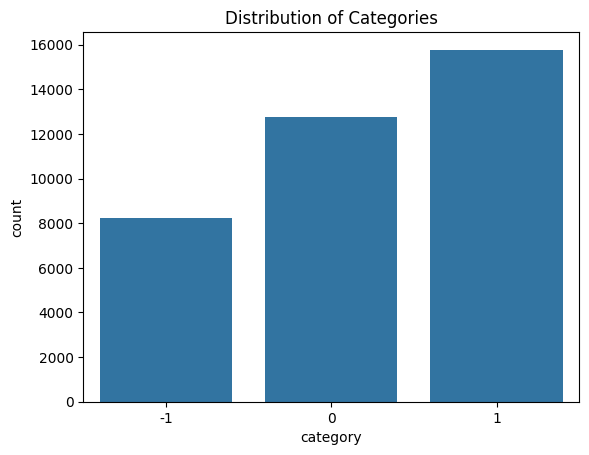

In [397]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='category', data=reddit_data)
plt.title('Distribution of Categories')

In [398]:
reddit_data.shape

(36793, 2)

In [399]:
# frequency distribution of categories
reddit_data['category'].value_counts(normalize=True).mul(100).round(2)

category
 1    42.86
 0    34.71
-1    22.42
Name: proportion, dtype: float64

In [400]:
reddit_data['word_count'] = reddit_data['clean_comment'].apply(lambda x: len(x.split()))

reddit_data.head()

,clean_comment,category,word_count
0,family mormon have never tried explain them th...,1,39
1,buddhism has very much lot compatible with chr...,1,196
2,seriously don say thing first all they won get...,-1,86
3,what you have learned yours and only yours wha...,0,29
4,for your own benefit you may want read living ...,1,112


In [401]:
reddit_data['word_count'].describe()

count    36793.000000
mean        29.673090
std         56.793091
min          1.000000
25%          6.000000
50%         13.000000
75%         30.000000
max       1307.000000
Name: word_count, dtype: float64

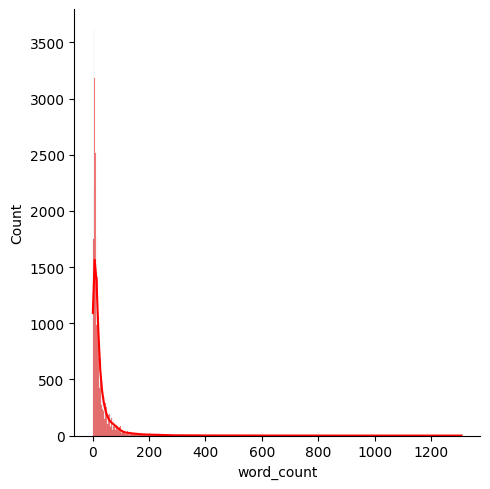

In [402]:
#plot display of word count distribution
sns.displot(reddit_data['word_count'], kde=True, color='red', legend= True)

In [403]:
plt.figure(figsize=(10,6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

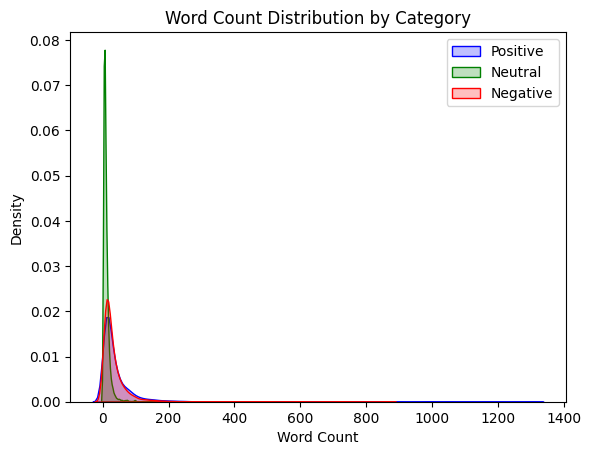

In [404]:
## plot sns.kdeplot for each category 1
sns.kdeplot(reddit_data[reddit_data['category'] == 1]['word_count'], label = 'Positive', fill=True, color='blue')
##plot sns.kdeplot for category 0
sns.kdeplot(reddit_data[reddit_data['category'] == 0]['word_count'], label = 'Neutral', fill=True, color='green')
##plot sns.kdeplot for category -1
sns.kdeplot(reddit_data[reddit_data['category'] == -1]['word_count'], label = 'Negative', fill=True, color='red')

## Add title and labels
plt.title('Word Count Distribution by Category')
plt.xlabel('Word Count')
plt.ylabel('Density')

## Add a legend
plt.legend()

## show the plot
plt.show()

<Axes: ylabel='word_count'>

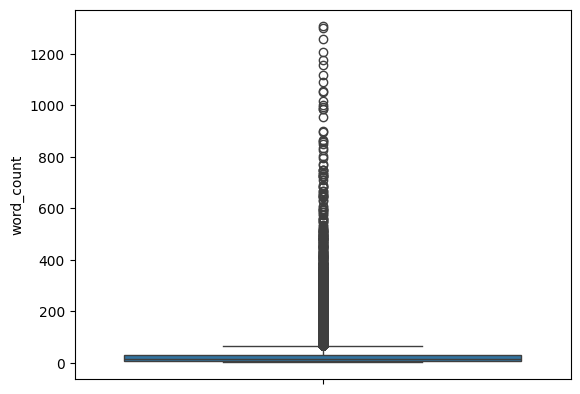

In [405]:
sns.boxplot(reddit_data['word_count'])

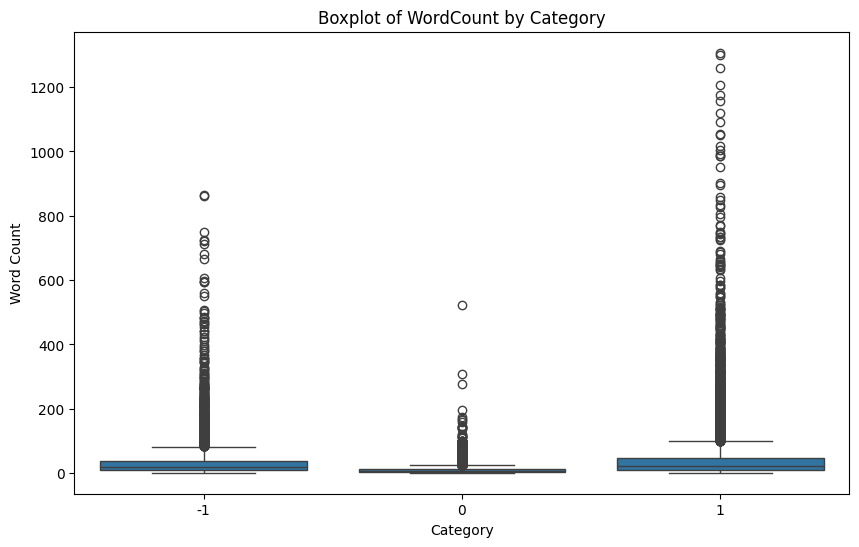

In [406]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=reddit_data, x='category', y='word_count')
plt.title('Boxplot of WordCount by Category')
plt.xlabel('Category')
plt.ylabel('Word Count')
plt.show()

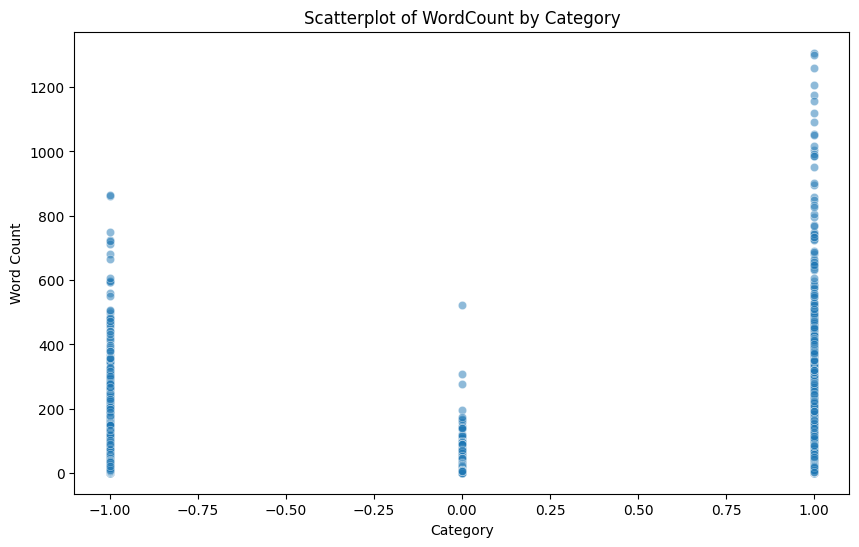

In [407]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=reddit_data, x='category', y='word_count', alpha=0.5)
plt.title('Scatterplot of WordCount by Category')
plt.xlabel('Category')
plt.ylabel('Word Count')
plt.show()

<Axes: xlabel='category', ylabel='word_count'>

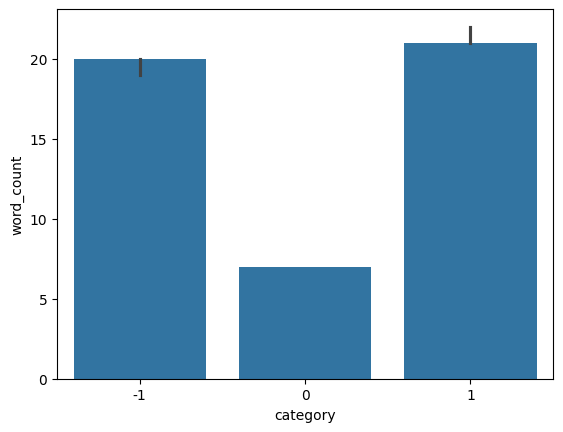

In [408]:
sns.barplot(reddit_data, x='category', y='word_count', estimator='median')

In [409]:
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

reddit_data['num_stop_words'] = reddit_data['clean_comment'].apply(lambda x: len([word for word in x.split() if word in stop_words]))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ajjain\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [410]:
reddit_data.sample(5)

,clean_comment,category,word_count,num_stop_words
23760,notice trend people ordering cai png without p...,1,23,4
12957,coming soon agnipareeksha passport verification,0,5,0
1070,much the chaddiwalas out here india and facebo...,1,47,19
13773,has that post been deleted from the jayadev fe...,1,42,21
27821,the terrorist attacks your country are your co...,1,18,7


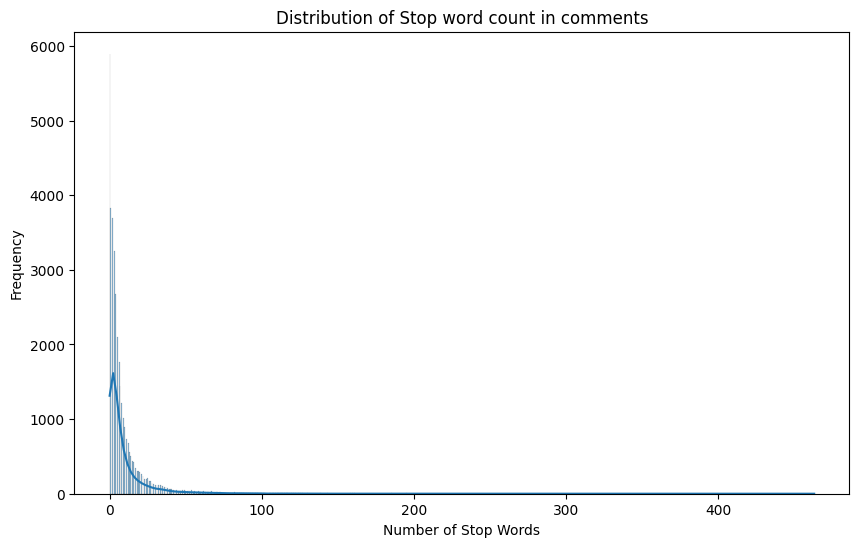

In [411]:
plt.figure(figsize=(10, 6))
sns.histplot(reddit_data['num_stop_words'], kde=True)
plt.title('Distribution of Stop word count in comments')
plt.xlabel('Number of Stop Words')
plt.ylabel('Frequency')
plt.show()

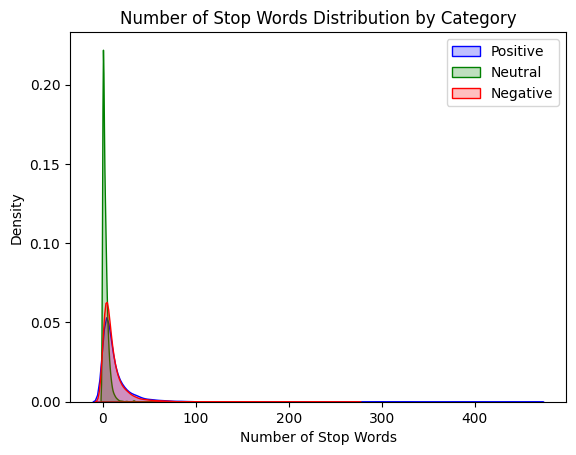

In [412]:
## plot sns.kdeplot for each category 1
sns.kdeplot(reddit_data[reddit_data['category'] == 1]['num_stop_words'], label = 'Positive', fill=True, color='blue')
##plot sns.kdeplot for category 0
sns.kdeplot(reddit_data[reddit_data['category'] == 0]['num_stop_words'], label = 'Neutral', fill=True, color='green')
##plot sns.kdeplot for category -1
sns.kdeplot(reddit_data[reddit_data['category'] == -1]['num_stop_words'], label = 'Negative', fill=True, color='red')

## Add title and labels
plt.title('Number of Stop Words Distribution by Category')
plt.xlabel('Number of Stop Words')
plt.ylabel('Density')

## Add a legend
plt.legend()

## show the plot
plt.show()

<Axes: xlabel='category', ylabel='num_stop_words'>

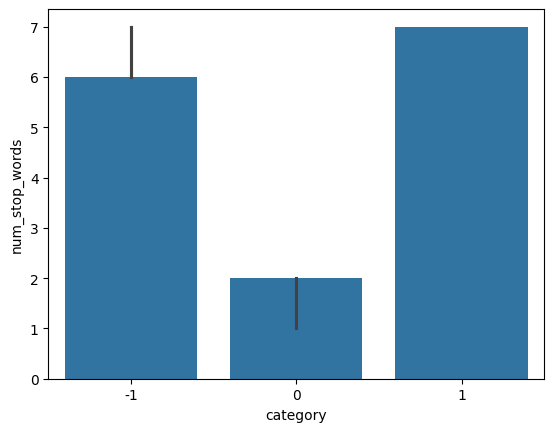

In [413]:
sns.barplot(reddit_data, x='category', y='num_stop_words', estimator='median')

C:\Users\ajjain\AppData\Local\Temp\ipykernel_8776\583949559.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_df, x='count', y='stop_word', palette='viridis')


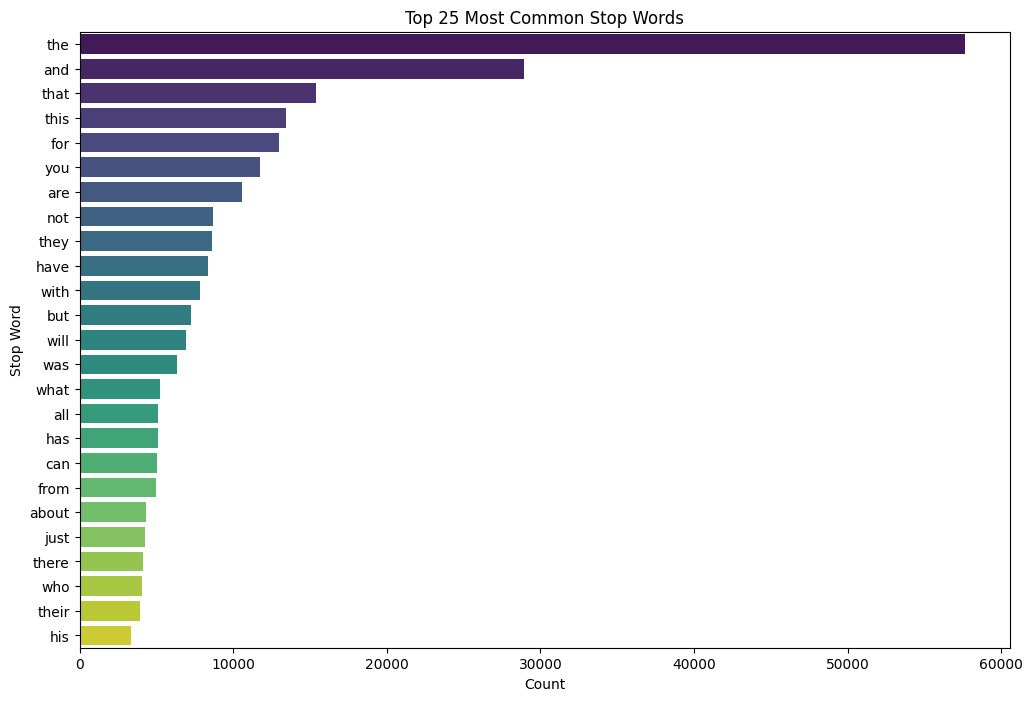

In [414]:
from collections import Counter

# Extract all stop words from the comments using the previously defined 'common_stopwords'
all_stop_words = [word for comment in reddit_data['clean_comment'] for word in comment.split() if word in stop_words]

# Count the most common stop words
most_common_stop_words = Counter(all_stop_words).most_common(25)

# Convert the most common stop words to a DataFrame for plotting
top_25_df = pd.DataFrame(most_common_stop_words, columns=['stop_word', 'count'])

# Create the barplot for the top 25 most common stop words
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_df, x='count', y='stop_word', palette='viridis')
plt.title('Top 25 Most Common Stop Words')
plt.xlabel('Count')
plt.ylabel('Stop Word')
plt.show()

In [415]:
reddit_data['num_chars'] = reddit_data['clean_comment'].apply(len)

In [416]:
reddit_data

,clean_comment,category,word_count,num_stop_words,num_chars
0,family mormon have never tried explain them th...,1,39,13,259
1,buddhism has very much lot compatible with chr...,1,196,59,1268
2,seriously don say thing first all they won get...,-1,86,40,459
3,what you have learned yours and only yours wha...,0,29,15,167
4,for your own benefit you may want read living ...,1,112,45,690
...,...,...,...,...,...
37244,jesus,0,1,0,5
37245,kya bhai pure saal chutiya banaya modi aur jab...,1,19,0,99
37246,downvote karna tha par upvote hogaya,0,6,0,36
37247,haha nice,1,2,0,9


In [417]:
from collections import Counter

# Combine all comments into one large string
all_text = ' '.join(reddit_data['clean_comment'])

# Count the frequency of each character
char_frequency = Counter(all_text)

# Convert the character frequency into a DataFrame for better display
char_frequency_df = pd.DataFrame(char_frequency.items(), columns=['character', 'frequency']).sort_values(by='frequency', ascending=False)



In [418]:
char_frequency_df.values

array([[' ', 1091592],
       ['e', 666610],
       ['t', 491287],
       ['a', 481134],
       ['i', 401388],
       ['n', 388465],
       ['o', 379908],
       ['s', 355279],
       ['r', 331425],
       ['h', 296748],
       ['l', 250104],
       ['d', 221980],
       ['u', 170377],
       ['c', 167821],
       ['m', 155561],
       ['p', 135139],
       ['g', 132927],
       ['y', 115420],
       ['w', 110522],
       ['b', 88199],
       ['f', 78866],
       ['v', 66020],
       ['k', 62531],
       ['j', 22906],
       ['x', 9075],
       ['0', 8477],
       ['z', 5725],
       ['q', 5136],
       ['â', 5023],
       ['\x80', 4982],
       ['à', 4854],
       ['1', 4845],
       ['2', 4638],
       ['\x99', 2512],
       ['¤', 2344],
       ['¥', 2151],
       ['9', 1775],
       ['5', 1631],
       ['3', 1617],
       ['å', 1605],
       ['4', 1573],
       ['6', 1403],
       ['7', 1291],
       ['ä', 1210],
       ['8', 1199],
       ['¾', 1125],
       ['ã', 931],
       ['\x

In [419]:
char_frequency_df.tail(50)

,character,frequency
66,°,262
49,,249
92,,247
57,±,222
88,,206
81,²,203
114,,193
36,«,190
45,¦,188
82,®,182


In [420]:
# Create a new column 'num_punctuation_chars' to count punctuation characters in each comment
reddit_data['num_punctuation_chars'] = reddit_data['clean_comment'].apply(
    lambda x: sum([1 for char in x if char in '.,!?;:"\'()[]{}-'])
)

reddit_data.sample(5)

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
20539,every news media should this until modi relents,0,8,3,47,0
36204,free publicity,1,2,0,14,0
11524,only good things can come from closer ties bet...,1,18,7,106,0
19701,think they will back karnataka the state has h...,-1,25,8,150,0
27380,chalo right,1,2,0,11,0


C:\Users\ajjain\AppData\Local\Temp\ipykernel_8776\1211582460.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_bigrams_df, x='count', y='bigram', palette='magma')


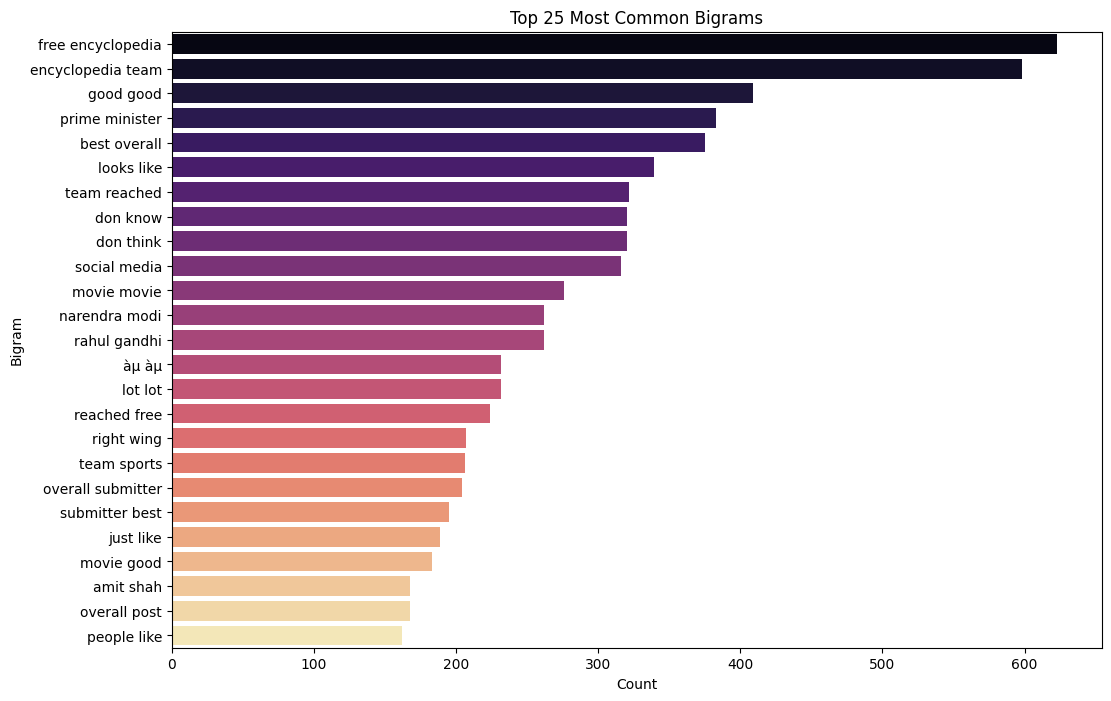

In [421]:
from sklearn.feature_extraction.text import CountVectorizer

# Create a function to extract the top 25 ngrams
def get_top_ngrams(corpus, no_of_grams, n=None):
    vec = CountVectorizer(ngram_range=(no_of_grams, no_of_grams), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# Get the top 25 bigrams
top_25_bigrams = get_top_ngrams(reddit_data['clean_comment'], 2, 25)

# Convert the bigrams into a DataFrame for plotting
top_25_bigrams_df = pd.DataFrame(top_25_bigrams, columns=['bigram', 'count'])

# Plot the countplot for the top 25 bigrams
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_bigrams_df, x='count', y='bigram', palette='magma')
plt.title('Top 25 Most Common Bigrams')
plt.xlabel('Count')
plt.ylabel('Bigram')
plt.show()


C:\Users\ajjain\AppData\Local\Temp\ipykernel_8776\3355616176.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_trirams_df, x='count', y='trigram', palette='magma')


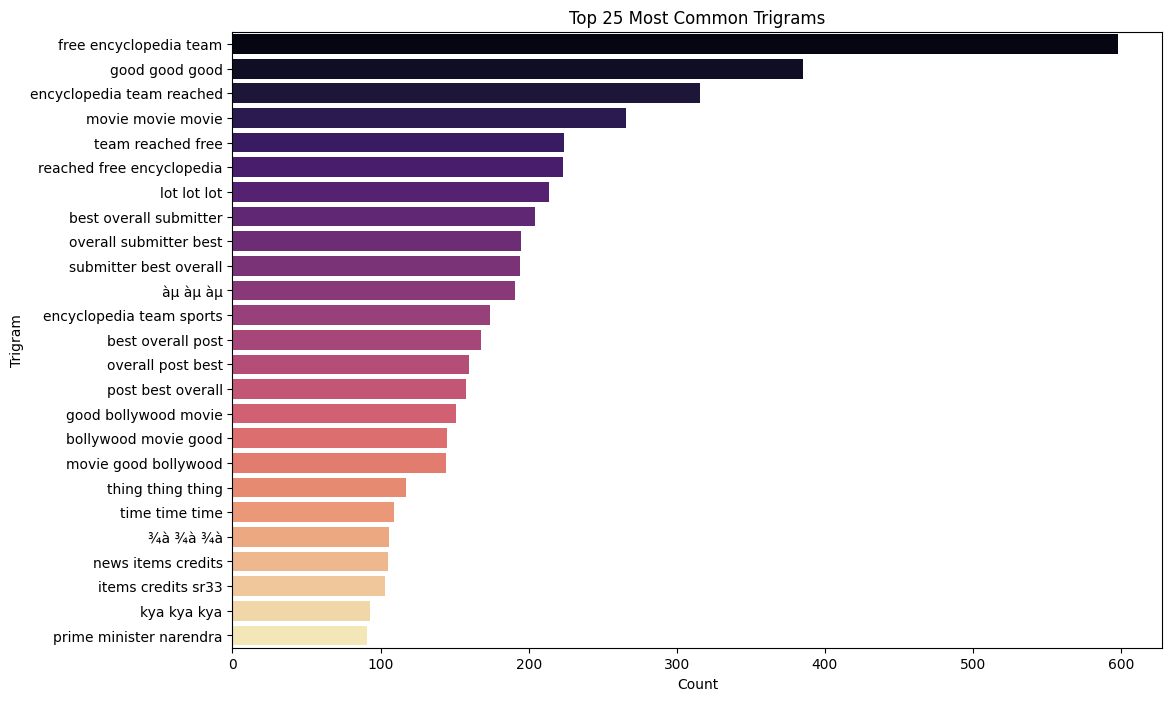

In [422]:
# Get the top 25 trigrams
top_25_trigrams = get_top_ngrams(reddit_data['clean_comment'], 3, 25)

# Convert the Trirams into a DataFrame for plotting
top_25_trirams_df = pd.DataFrame(top_25_trigrams, columns=['trigram', 'count'])

# Plot the countplot for the top 25 trigrams
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_trirams_df, x='count', y='trigram', palette='magma')
plt.title('Top 25 Most Common Trigrams')
plt.xlabel('Count')
plt.ylabel('Trigram')
plt.show()

In [423]:
# Remove non-English characters from the 'clean_comment' column
# Keeping only standard English letters, digits, and common punctuation
import re

reddit_data['clean_comment'] = reddit_data['clean_comment'].apply(lambda x: re.sub(pattern=r'[^A-Za-z0-9\s!?.,]', repl= '', string=str(x)))

In [424]:
# Combine all comments into one large string
all_text = ' '.join(reddit_data['clean_comment'])

# Count the frequency of each character
char_frequency = Counter(all_text)

# Convert the character frequency into a DataFrame for better display
char_frequency_df = pd.DataFrame(char_frequency.items(), columns=['character', 'frequency']).sort_values(by='frequency', ascending=False)


In [425]:
char_frequency_df.tail(50)

,character,frequency
6,,1091592
12,e,666610
13,t,491287
1,a,481134
3,i,401388
9,n,388465
7,o,379908
17,s,355279
8,r,331425
10,h,296748


In [426]:
from nltk.corpus import stopwords

# Defining stop words but keeping essential ones for sentiment analysis
stop_words = set(stopwords.words('english')) - {'not', 'but', 'however', 'no', 'yet'}

# Remove stop words from 'clean_comment' column, retaining essential ones
reddit_data['clean_comment'] = reddit_data['clean_comment'].apply(
    lambda x: ' '.join([word for word in x.split() if word.lower() not in stop_words])
)


In [427]:
reddit_data.head()

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,86,40,459,0
3,learned want teach different focus goal not wr...,0,29,15,167,0
4,benefit may want read living buddha living chr...,1,112,45,690,0


In [428]:
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

# Define the lemmatizer
lemmatizer = WordNetLemmatizer()

# Apply lemmatization to the 'clean_comment_no_stopwords' column
reddit_data['clean_comment'] = reddit_data['clean_comment'].apply(
    lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()])
)

reddit_data.head()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ajjain\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,86,40,459,0
3,learned want teach different focus goal not wr...,0,29,15,167,0
4,benefit may want read living buddha living chr...,1,112,45,690,0


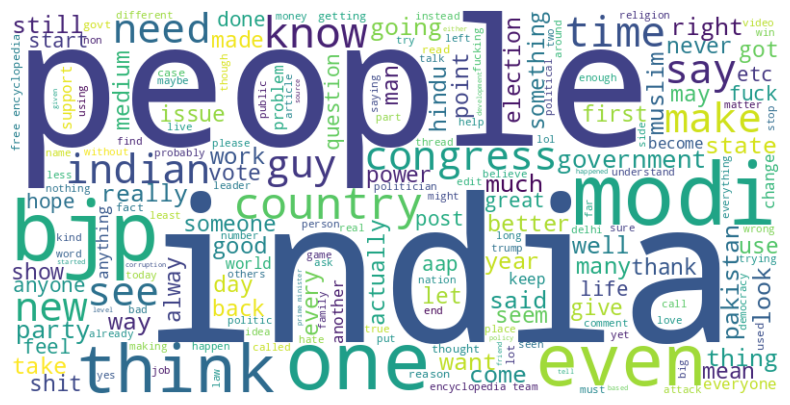

In [429]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

plot_word_cloud(reddit_data['clean_comment'])

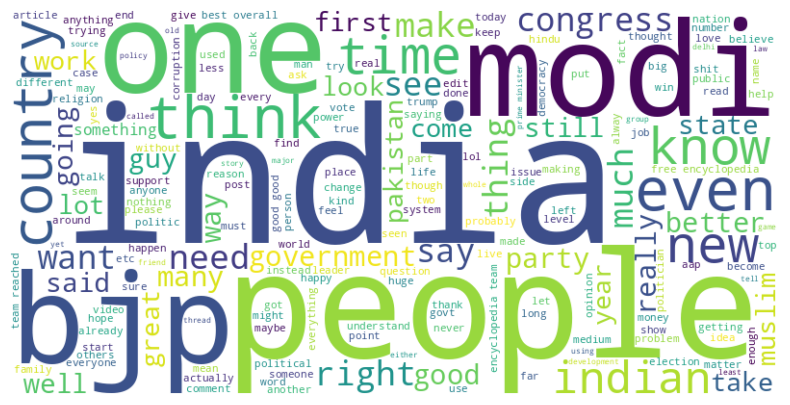

In [430]:
plot_word_cloud(reddit_data[reddit_data['category'] == 1]['clean_comment'])

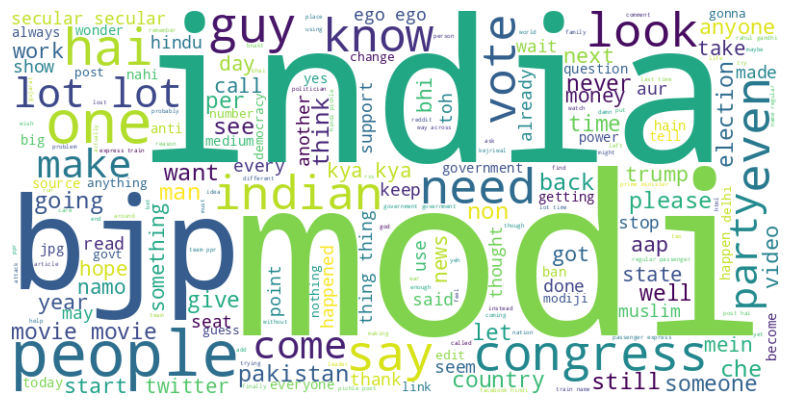

In [431]:
plot_word_cloud(reddit_data[reddit_data['category'] == 0]['clean_comment'])

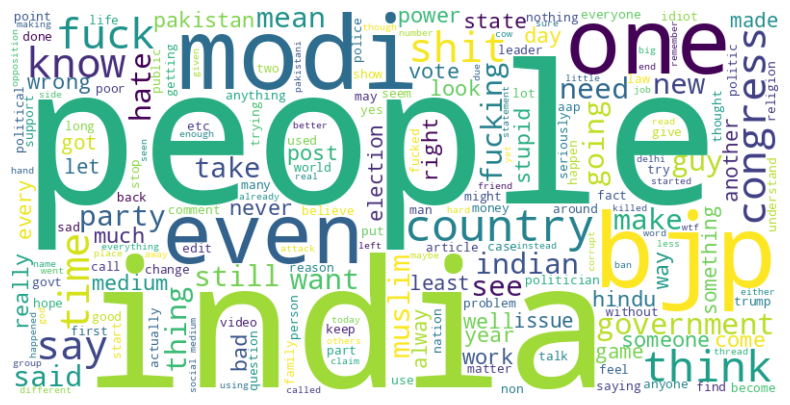

In [432]:
plot_word_cloud(reddit_data[reddit_data['category'] == -1]['clean_comment'])

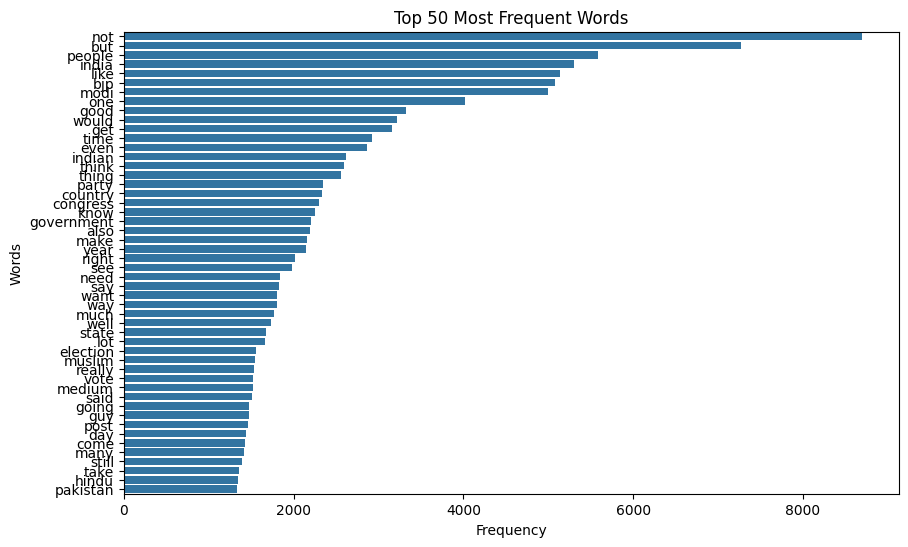

In [433]:
def plot_top_n_words(df, n=20):
    """Plot the top N most frequent words in the dataset."""
    # Flatten all words in the content column
    words = ' '.join(df['clean_comment']).split()

    # Get the top N most common words
    counter = Counter(words)
    most_common_words = counter.most_common(n)

    # Split the words and their counts for plotting
    ##words, counts = zip(*most_common_words)
    most_common_words_and_count = pd.DataFrame(most_common_words, columns=['words', 'count'])

    # Plot the top N words
    plt.figure(figsize=(10, 6))
    ##sns.barplot(x=list(counts), y=list(words))
    sns.barplot(most_common_words_and_count, x='count', y='words')
    plt.title(f'Top {n} Most Frequent Words')
    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.show()

# Example usage
plot_top_n_words(reddit_data, n=50)

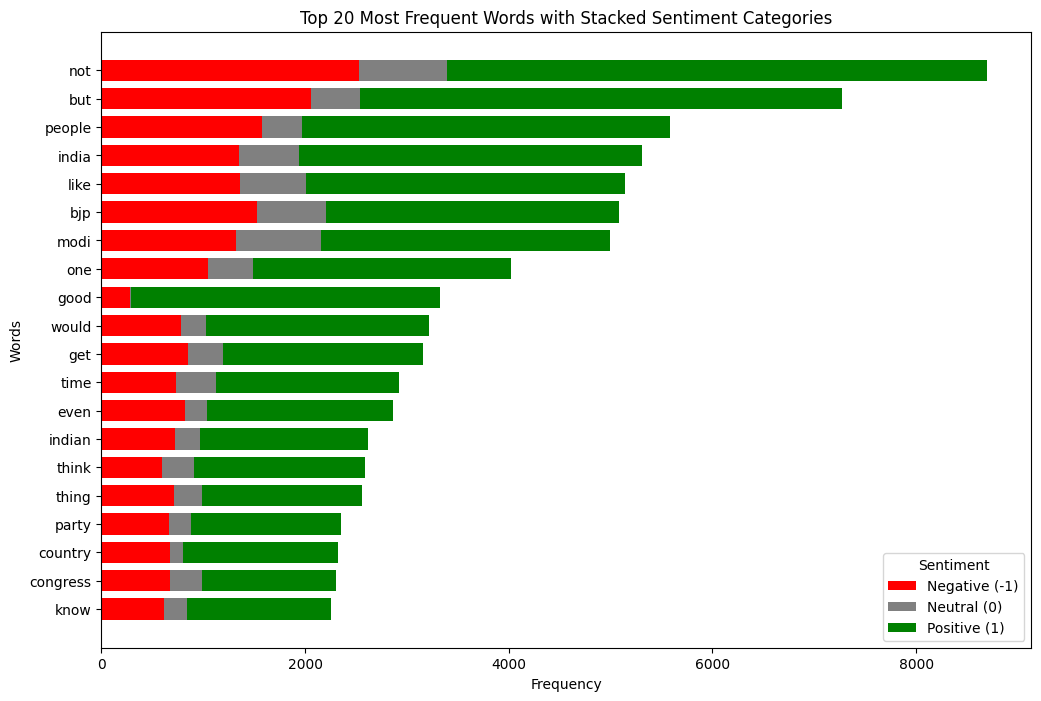

In [434]:
def plot_top_n_words_by_category(df, n=20, start=0):
    """Plot the top N most frequent words in the dataset with stacked hue based on sentiment category."""
    # Flatten all words in the content column and count their occurrences by category
    word_category_counts = {}

    for idx, row in df.iterrows():
        words = row['clean_comment'].split()
        category = row['category']  # Assuming 'category' column exists for -1, 0, 1 labels

        for word in words:
            if word not in word_category_counts:
                word_category_counts[word] = { -1: 0, 0: 0, 1: 0 }  # Initialize counts for each sentiment category

            # Increment the count for the corresponding sentiment category
            word_category_counts[word][category] += 1

    # Get total counts across all categories for each word
    total_word_counts = {word: sum(counts.values()) for word, counts in word_category_counts.items()}

    # Get the top N most frequent words across all categories
    most_common_words = sorted(total_word_counts.items(), key=lambda x: x[1], reverse=True)[start:start+n]
    top_words = [word for word, _ in most_common_words]

    # Prepare data for plotting
    word_labels = top_words
    negative_counts = [word_category_counts[word][-1] for word in top_words]
    neutral_counts = [word_category_counts[word][0] for word in top_words]
    positive_counts = [word_category_counts[word][1] for word in top_words]

    # Plot the stacked bar chart
    plt.figure(figsize=(12, 8))
    bar_width = 0.75

    # Plot negative, neutral, and positive counts in a stacked manner
    plt.barh(word_labels, negative_counts, color='red', label='Negative (-1)', height=bar_width)
    plt.barh(word_labels, neutral_counts, left=negative_counts, color='gray', label='Neutral (0)', height=bar_width)
    plt.barh(word_labels, positive_counts, left=[i+j for i,j in zip(negative_counts, neutral_counts)], color='green', label='Positive (1)', height=bar_width)

    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.title(f'Top {n} Most Frequent Words with Stacked Sentiment Categories')
    plt.legend(title='Sentiment', loc='lower right')
    plt.gca().invert_yaxis()  # Invert y-axis to show the highest frequency at the top
    plt.show()



plot_top_n_words_by_category(reddit_data, n=20)